In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

%matplotlib inline

In [2]:
def plot_graphs(log, tpe='loss'):
    keys = log.keys()
    logs = {k:[z for z in zip(*log[k])] for k in keys}
    epochs = {k:range(len(log[k])) for k in keys}
    
    if tpe == 'loss':
        handlers, = zip(*[plt.plot(epochs[k], logs[k][0], label=k)
                          for k in keys])
        plt.title('errors')
        plt.xlabel('epoch')
        plt.ylabel('error')
        plt.legend(handles=handlers)
        plt.show()
        
    elif tpe == 'accuracy':
        handlers, = zip(*[plt.plot(epochs[k], logs[k][1], label=k)
                          for k in log.keys()])
        plt.title('accuracy')
        plt.xlabel('epoch')
        plt.ylabel('accuracy')
        plt.legend(handles=handlers)
        plt.show()

In [3]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))
])
path = './MNIST_data'
batch_size = 32

In [6]:
test_data = datasets.MNIST(path, train=False,
                           download=True, transform=mnist_transform)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

train_data = datasets.MNIST(path, train=True,
                            download=True, transform=mnist_transform)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [7]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

In [8]:
example_data.shape

torch.Size([32, 1, 28, 28])

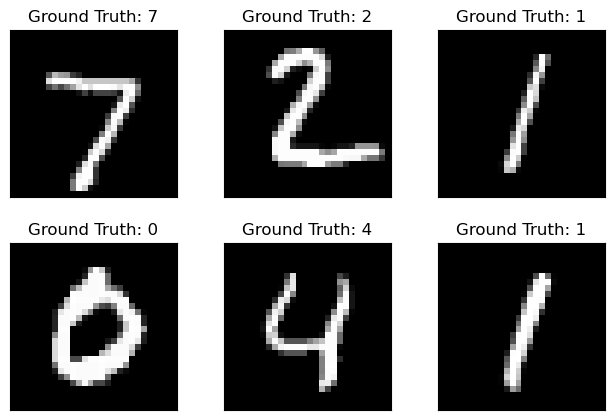

In [10]:
fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])


In [ ]:
class Net(nn.Module):
    def __init__(self,
                 batchnorm=False,
                 dropout=False,
                 lr=1e-4, l2=0.):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 10)
        if batchnorm:
            self.bn = nn.BatchNorm1d(128)
        else:
            self.bn = lambda x: x
        if dropout:
            self.dropout = nn.Dropout(0.2)
        else:
            self.dropout = lambda x: x
        self.optim = optim.SGD(self.parameters(), lr=lr, weight_decay=l2)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = self.bn(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        x = F.log_softmax(x, dim=1)
        return x

    def loss(self, output, target, **kwargs):
        # критерий считается "на метсе" без предварительной инициализации nn.NLLLoss
        self._loss = F.nll_loss(output, target, **kwargs)
        # output.data возвращает только веса
        # dim=1 - максимальные значения ищутся в строках и возвращаются вместе с индексами, которые и берутся в качестве результата. В конце- [1]
        # keepdim=True позволяет сохранить первичную структуру измерений, в данном случае - вместо одномерного списка индексов возвращается 32 (по размеру батча) списка по одному элементу
        pred = output.data.max(dim=1, keepdim=True)[1]
        # приведение исходных правильных ответов к формату предсказаний - 32 списка по одному элементу 
        t = target.data.view_as(pred)
        # сохраняется среднее число совпадений по батчу
        # используется для итогового вывода по обучению
        self._correct = pred.eq(t).to(torch.float).mean()
        return self._loss

In [12]:
models = {'default': Net(),
          'batchorm': Net(batchnorm=True),
          'dropout': Net(dropout=True),
          'batchnorm with dropout': Net(batchnorm=True, dropout=True)}
train_log = {k: [] for k in models}
test_log = {k: [] for k in models}

In [63]:
def train(models, loader, epoch, log=None):
    train_size = len(loader.sampler)
    for batch_idx, (data, target) in enumerate(loader):
        for model in models.values():
            model.optim.zero_grad()
            output = model(data)
            loss = model.loss(output, target)
            loss.backward()
            model.optim.step()
            
        if batch_idx % 200 == 0:
            line = 'Train Epoch: {} [{}/{} ({:.0f}%)]\tLosses '.format(
                epoch, batch_idx * len(data), train_size, 100. * batch_idx / len(train_loader))
            losses = ' '.join(['{}: {:.6f}'.format(k, m._loss.item()) for k, m in models.items()])
            print(line + losses)
            
    else:
        batch_idx += 1
        line = 'Train Epoch: {} [{}/{} ({:.0f}%)]\tLosses '.format(
            epoch, batch_idx * len(data), train_size, 100. * batch_idx / len(train_loader))
        losses = ' '.join(['{}: {:.6f}'.format(k, m._loss.item()) for k, m in models.items()])
        if log is not None:
            for k in models:
                log[k].append((models[k]._loss, models[k]._correct))
        print(line + losses)

In [64]:
def test(models, loader, log=None):
    test_size = len(loader.sampler)
    avg_lambda = lambda l: 'Loss: {:.4f}'.format(l)
    acc_lambda = lambda c, p: 'Accuracy: {}/{} ({:.0f}%)'.format(c, test_size, p)
    line = lambda i, l, c, p: '{}: '.format(i) + avg_lambda(l) + '\t' + acc_lambda(c, p)

    test_loss = {k: 0. for k in models}
    correct = {k: 0. for k in models}
    with torch.no_grad():
        for data, target in loader:
            output = {k: m(data) for k, m in models.items()}
            for k, m in models.items():
                test_loss[k] += m.loss(output[k], target, reduction='sum').item() # sum up batch loss
                pred = output[k].data.max(1, keepdim=True)[1] # get the index of the max log-probability
                correct[k] += pred.eq(target.data.view_as(pred)).cpu().sum()
    
    for k in models:
        test_loss[k] /= test_size
    correct_pct = {k: c.to(torch.float) / test_size for k, c in correct.items()}
    lines = '\n'.join([line(k, test_loss[k], correct[k], 100*correct_pct[k]) for k in models]) + '\n'
    report = 'Test set:\n' + lines
    if log is not None:
        for k in models:
            log[k].append((test_loss[k], correct_pct[k]))
    print(report)

In [65]:
for epoch in range(1, 51):
    for model in models.values():
        model.train()
    train(models, train_loader, epoch, train_log)
    for model in models.values():
        model.eval()
    test(models, test_loader, test_log)

Train Epoch: 1 [0/60000 (0%)]	Losses default: 2.275146 batchorm: 2.306102 dropout: 2.319509 batchnorm with dropout: 2.388262
Train Epoch: 1 [6400/60000 (11%)]	Losses default: 2.292338 batchorm: 2.253942 dropout: 2.285765 batchnorm with dropout: 2.351597
Train Epoch: 1 [12800/60000 (21%)]	Losses default: 2.297998 batchorm: 2.234136 dropout: 2.270739 batchnorm with dropout: 2.232988
Train Epoch: 1 [19200/60000 (32%)]	Losses default: 2.286103 batchorm: 2.247404 dropout: 2.286499 batchnorm with dropout: 2.237488
Train Epoch: 1 [25600/60000 (43%)]	Losses default: 2.286590 batchorm: 2.126415 dropout: 2.277939 batchnorm with dropout: 2.243027
Train Epoch: 1 [32000/60000 (53%)]	Losses default: 2.293930 batchorm: 2.130487 dropout: 2.250299 batchnorm with dropout: 2.110930
Train Epoch: 1 [38400/60000 (64%)]	Losses default: 2.285418 batchorm: 2.074873 dropout: 2.300235 batchnorm with dropout: 2.132084
Train Epoch: 1 [44800/60000 (75%)]	Losses default: 2.246859 batchorm: 2.037647 dropout: 2.243990

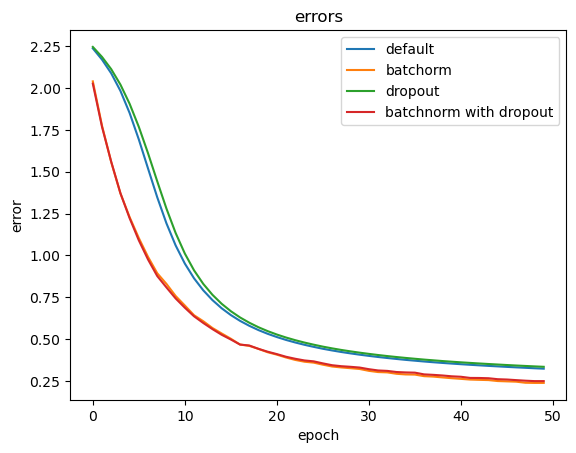

In [13]:
plot_graphs(test_log, 'loss')

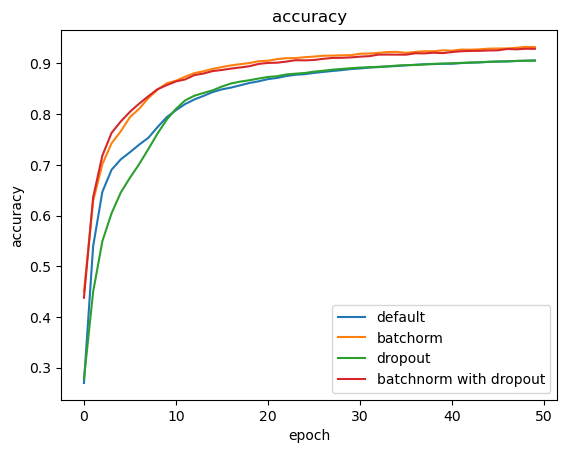

In [14]:
plot_graphs(test_log, 'accuracy')

## Влияние размера батча

В предыдущем примере размер батча был 32. Возмем больше - 256. Это ускорит обучение, но ухудшит его качество.

In [15]:
batch_size = 256
test_data = datasets.MNIST(path, train=False,
                           download=True, transform=mnist_transform)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

train_data = datasets.MNIST(path, train=True,
                            download=True, transform=mnist_transform)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [16]:
# очистим логи и создадим новые модели
models = {'default': Net(),
            'batchorm': Net(batchnorm=True),
            'dropout': Net(dropout=True),
            'batchnorm with dropout': Net(batchnorm=True, dropout=True)}

train_log = {k: [] for k in models}
test_log = {k: [] for k in models}

In [17]:
for epoch in range(1, 51):
    for model in models.values():
        model.train()
    train(models, train_loader, epoch, train_log)
    for model in models.values():
        model.eval()
    test(models, test_loader, test_log)

Train Epoch: 1 [0/60000 (0%)]	Losses default: 2.294670 batchorm: 2.335898 dropout: 2.322989 batchnorm with dropout: 2.344102
Train Epoch: 1 [51200/60000 (85%)]	Losses default: 2.298663 batchorm: 2.264545 dropout: 2.321319 batchnorm with dropout: 2.318092
Train Epoch: 1 [22560/60000 (100%)]	Losses default: 2.262121 batchorm: 2.248587 dropout: 2.297544 batchnorm with dropout: 2.296773
Test set:
default: Loss: 2.2863	Accuracy: 1694.0/10000 (17%)
batchorm: Loss: 2.2657	Accuracy: 1673.0/10000 (17%)
dropout: Loss: 2.3046	Accuracy: 1309.0/10000 (13%)
batchnorm with dropout: Loss: 2.3001	Accuracy: 1447.0/10000 (14%)

Train Epoch: 2 [0/60000 (0%)]	Losses default: 2.286270 batchorm: 2.268405 dropout: 2.301887 batchnorm with dropout: 2.328230
Train Epoch: 2 [51200/60000 (85%)]	Losses default: 2.284827 batchorm: 2.253274 dropout: 2.305166 batchnorm with dropout: 2.304695
Train Epoch: 2 [22560/60000 (100%)]	Losses default: 2.282109 batchorm: 2.222216 dropout: 2.320771 batchnorm with dropout: 2.2479

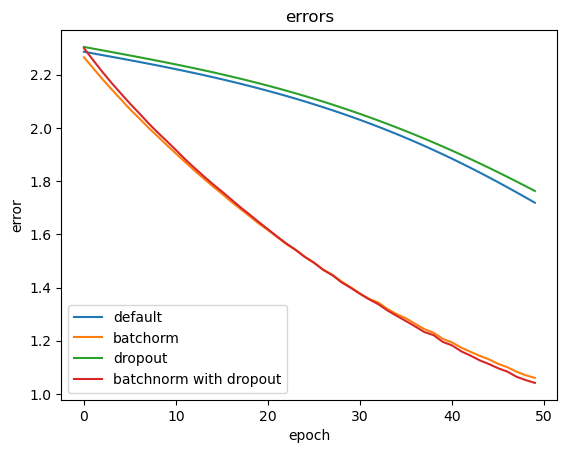

In [18]:
plot_graphs(test_log, 'loss')

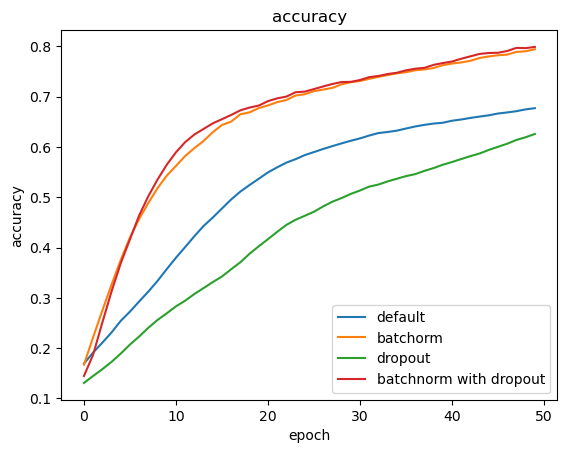

In [19]:
plot_graphs(test_log, 'accuracy')

# L2 регуляризация

In [20]:
class Net(nn.Module):
    def __init__(self,
                 batchnorm=False,
                 dropout=False,
                 opt='adamw',
                 lr=1e-4, l2=0.01):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 10)
        if batchnorm:
            self.bn = nn.BatchNorm1d(128)
        else:
            self.bn = lambda x: x
        if dropout:
            self.dropout = nn.Dropout(0.2)
        else:
            self.dropout = lambda x: x

        if opt == 'adamw':
            self.optim = optim.AdamW(self.parameters(), lr=lr, weight_decay=l2)
        else:
            self.optim = optim.SGD(self.parameters(), lr=lr)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = self.bn(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        x = F.log_softmax(x, dim=1)
        return x

    def loss(self, output, target, **kwargs):
        self._loss = F.nll_loss(output, target, **kwargs)
        pred = output.data.max(1, keepdim=True)[1]
        t = target.data.view_as(pred)
        self._correct = pred.eq(t).to(torch.float).mean()
        return self._loss

In [21]:
batch_size = 32
test_data = datasets.MNIST(path, train=False,
                           download=True, transform=mnist_transform)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

train_data = datasets.MNIST(path, train=True,
                            download=True, transform=mnist_transform)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [22]:
# 'SGD': Net(batchnorm=True, dropout=True, opt='sgd'),
models = {'AdamW_l2': Net(batchnorm=True, dropout=True, opt='adamw'),
          'AdamW': Net(batchnorm=True, dropout=True, opt='adamw', l2=0.),}

train_log = {k: [] for k in models}
test_log = {k: [] for k in models}

In [23]:
for epoch in range(1, 20):
    for model in models.values():
        model.train()
    train(models, train_loader, epoch, train_log)
    for model in models.values():
        model.eval()
    test(models, test_loader, test_log)

Train Epoch: 1 [0/60000 (0%)]	Losses AdamW_l2: 2.317381 AdamW: 2.297587
Train Epoch: 1 [6400/60000 (11%)]	Losses AdamW_l2: 0.927351 AdamW: 0.930167
Train Epoch: 1 [12800/60000 (21%)]	Losses AdamW_l2: 0.515960 AdamW: 0.587673
Train Epoch: 1 [19200/60000 (32%)]	Losses AdamW_l2: 0.316541 AdamW: 0.289405
Train Epoch: 1 [25600/60000 (43%)]	Losses AdamW_l2: 0.295221 AdamW: 0.347773
Train Epoch: 1 [32000/60000 (53%)]	Losses AdamW_l2: 0.401376 AdamW: 0.453054
Train Epoch: 1 [38400/60000 (64%)]	Losses AdamW_l2: 0.317485 AdamW: 0.357975
Train Epoch: 1 [44800/60000 (75%)]	Losses AdamW_l2: 0.255798 AdamW: 0.216852
Train Epoch: 1 [51200/60000 (85%)]	Losses AdamW_l2: 0.382280 AdamW: 0.422991
Train Epoch: 1 [57600/60000 (96%)]	Losses AdamW_l2: 0.179198 AdamW: 0.181325
Train Epoch: 1 [60000/60000 (100%)]	Losses AdamW_l2: 0.305571 AdamW: 0.263584
Test set:
AdamW_l2: Loss: 0.2003	Accuracy: 9427.0/10000 (94%)
AdamW: Loss: 0.1928	Accuracy: 9429.0/10000 (94%)

Train Epoch: 2 [0/60000 (0%)]	Losses AdamW_l2:

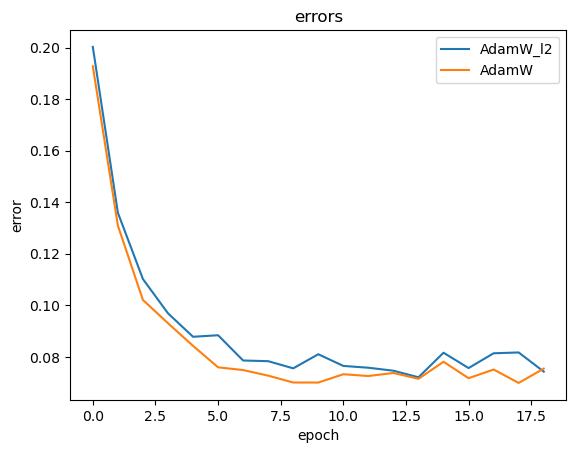

In [24]:
plot_graphs(test_log, 'loss')

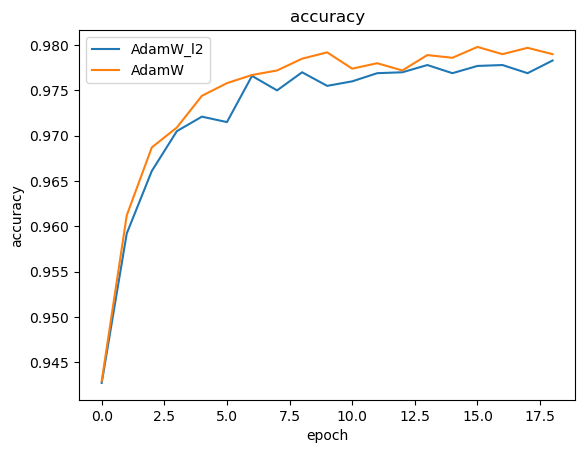

In [25]:
plot_graphs(test_log, 'accuracy')